# 02 - Data Cleaning and Preprocessing

## Objective
This notebook handles:
- Missing value detection and imputation
- Duplicate removal
- Outlier detection and treatment
- Data type optimization
- Feature engineering (time-based features)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the data from previous notebook
PROCESSED_PATH = os.path.join('..', 'data', 'processed')
df = pd.read_pickle(os.path.join(PROCESSED_PATH, 'df_loaded.pkl'))

print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")

Data loaded: 2,075,259 rows × 8 columns
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


## 1. Handle Missing Values

In [3]:
# Analyze missing values in detail
print("Missing Values Summary:")
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
    'Data_Type': df.dtypes
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
display(missing_summary)

print(f"\nTotal records with any missing value: {df.isnull().any(axis=1).sum():,}")
print(f"Percentage of affected records: {(df.isnull().any(axis=1).sum() / len(df)) * 100:.2f}%")

Missing Values Summary:


,Column,Missing_Count,Missing_Percentage,Data_Type
Global_active_power,Global_active_power,25979,1.251844,float64
Global_reactive_power,Global_reactive_power,25979,1.251844,float64
Voltage,Voltage,25979,1.251844,float64
Global_intensity,Global_intensity,25979,1.251844,float64
Sub_metering_1,Sub_metering_1,25979,1.251844,float64
Sub_metering_2,Sub_metering_2,25979,1.251844,float64
Sub_metering_3,Sub_metering_3,25979,1.251844,float64



Total records with any missing value: 25,979
Percentage of affected records: 1.25%


In [4]:
# Check if missing values occur together (entire rows missing)
missing_pattern = df[df.isnull().any(axis=1)]
print(f"Sample of rows with missing values:")
display(missing_pattern.head(10))

# Check if all columns are missing in the same rows
all_missing = df[df.isnull().all(axis=1)]
print(f"\nRows where ALL values are missing: {len(all_missing):,}")

Sample of rows with missing values:


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,2006-12-21 11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6840,2006-12-21 11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19724,2006-12-30 10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19725,2006-12-30 10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41832,2007-01-14 18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61909,2007-01-28 17:13:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98254,2007-02-22 22:58:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98255,2007-02-22 22:59:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
142588,2007-03-25 17:52:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190497,2007-04-28 00:21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Rows where ALL values are missing: 0


In [3]:
# Strategy: For power consumption data, we'll use different imputation methods
# Option 1: Remove rows with missing values (if percentage is small)
# Option 2: Forward fill (use previous valid observation)
# Option 3: Interpolation (linear for time series)

print("Imputation Strategy:")
missing_pct = (df.isnull().any(axis=1).sum() / len(df)) * 100

if missing_pct < 5:
    print(f"Missing data is {missing_pct:.2f}% - using row removal")
    df_clean = df.dropna()
    print(f"Rows removed: {len(df) - len(df_clean):,}")
else:
    print(f"Missing data is {missing_pct:.2f}% - using interpolation")
    df_clean = df.copy()
    # Set datetime as index for proper time-series interpolation
    df_clean = df_clean.set_index('datetime')
    
    # Interpolate numeric columns
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method='time', limit_direction='both')
    
    # Reset index
    df_clean = df_clean.reset_index()
    print(f"Values interpolated: {df.isnull().sum().sum():,}")

print(f"\nCleaned dataset shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")

Imputation Strategy:
Missing data is 1.25% - using row removal
Rows removed: 25,979

Cleaned dataset shape: 2,049,280 rows × 8 columns
Remaining missing values: 0


## 2. Handle Duplicates

In [4]:
# Check for duplicate records
duplicates = df_clean.duplicated()
print(f"Duplicate rows: {duplicates.sum():,}")

if duplicates.sum() > 0:
    print(f"Sample of duplicate rows:")
    display(df_clean[duplicates].head())
    
    # Remove duplicates
    df_clean = df_clean.drop_duplicates()
    print(f"Duplicates removed. New shape: {df_clean.shape}")
else:
    print("No duplicate rows found.")

Duplicate rows: 0
No duplicate rows found.


In [5]:
# Check for duplicate timestamps
duplicate_times = df_clean['datetime'].duplicated()
print(f"Duplicate timestamps: {duplicate_times.sum():,}")

if duplicate_times.sum() > 0:
    print("Sample of duplicate timestamps:")
    display(df_clean[duplicate_times].head())
    
    # Keep first occurrence
    df_clean = df_clean.drop_duplicates(subset=['datetime'], keep='first')
    print(f"Duplicate timestamps removed. New shape: {df_clean.shape}")

Duplicate timestamps: 0


## 3. Outlier Detection and Treatment

In [ ]:
# Detect outliers using IQR method
def detect_outliers_iqr(data, column, factor=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("Outlier Analysis (IQR Method):")
outlier_summary = []
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_columns:
    outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    outlier_summary.append({
        'Column': col,
        'Outlier_Count': len(outliers),
        'Outlier_Percentage': (len(outliers) / len(df_clean)) * 100,
        'Lower_Bound': lower,
        'Upper_Bound': upper
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

Outlier Analysis (IQR Method):


,Column,Outlier_Count,Outlier_Percentage,Lower_Bound,Upper_Bound
0,Global_active_power,94907,4.631236,-1.522,3.358
1,Global_reactive_power,40420,1.972400,-0.171,0.413
2,Voltage,51067,2.491948,233.140,248.740
3,Global_intensity,100961,4.926657,-6.100,13.900
4,Sub_metering_1,169105,8.251923,0.000,0.000
5,Sub_metering_2,77151,3.764786,-1.500,2.500
6,Sub_metering_3,0,0.000000,-25.500,42.500


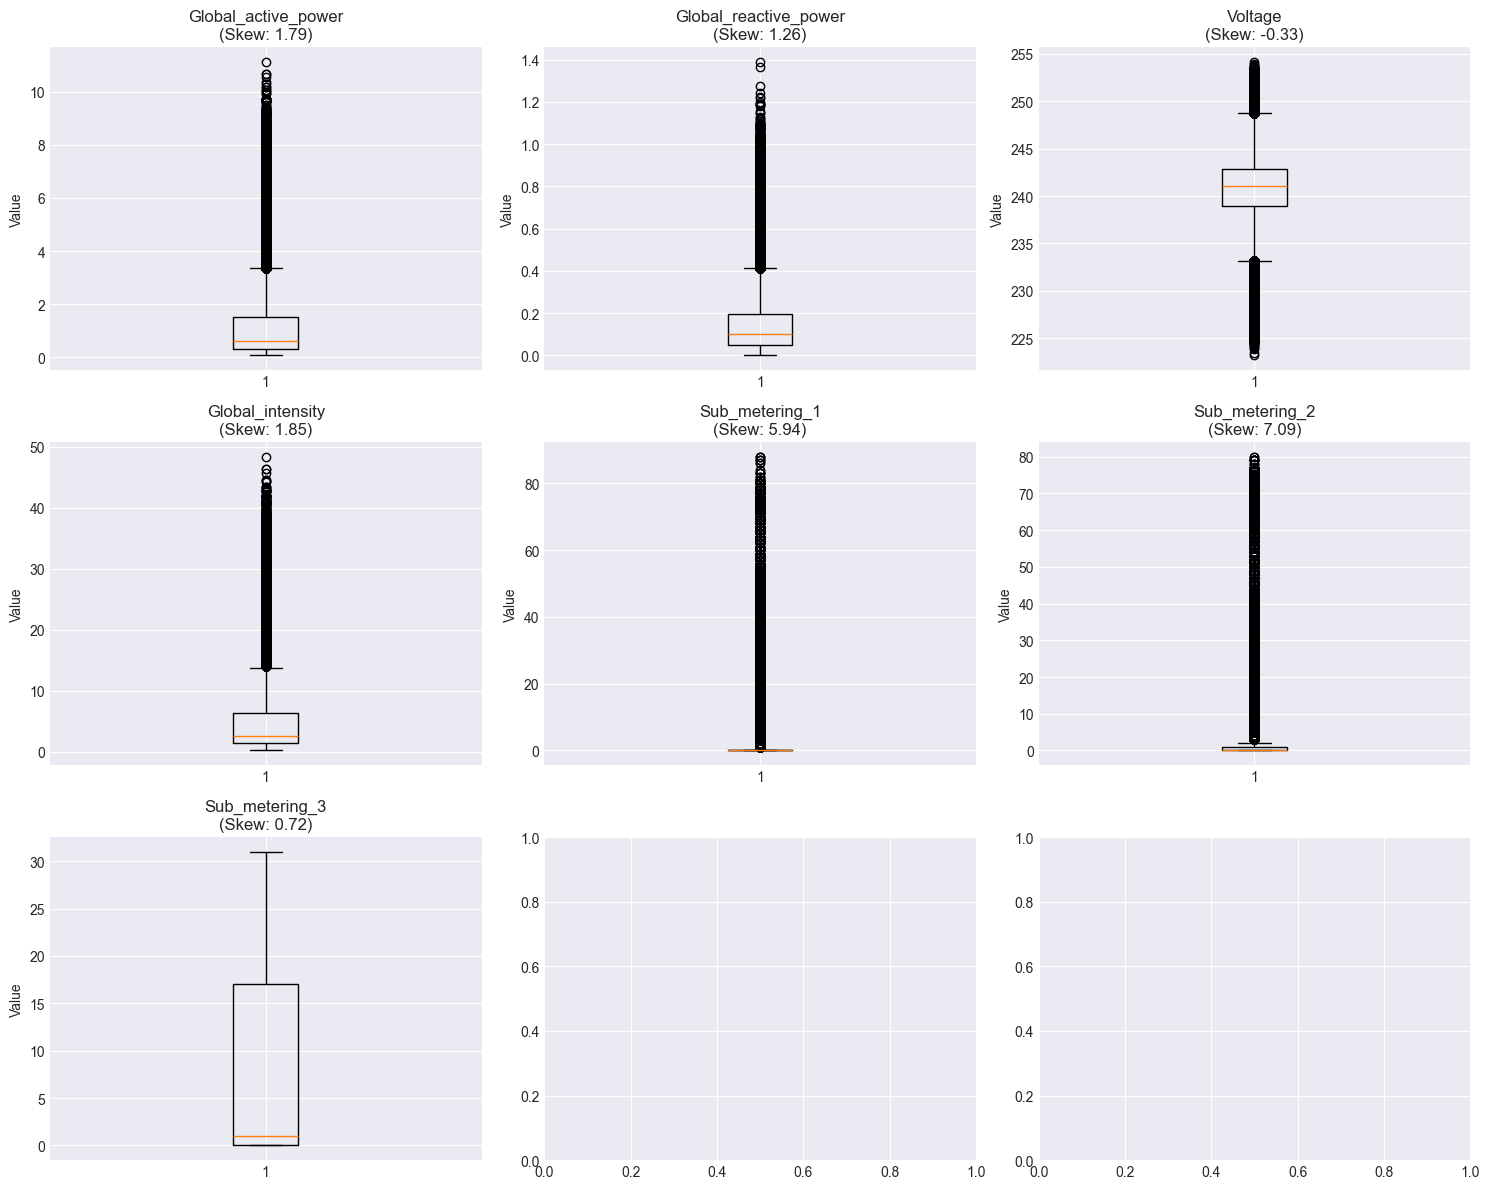

Boxplot saved to: outputs/figures/outliers_boxplot.png
Note: Log scale applied to highly skewed columns: Sub_metering_1, Sub_metering_2


In [16]:
# Visualize outliers with box plots (regular and log scale for skewed data)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

# Identify highly skewed columns (skewness > 3)
skewed_cols = []
for col in numeric_columns:
    skew_val = df_clean[col].skew()
    if abs(skew_val) > 3:
        skewed_cols.append(col)

for idx, col in enumerate(numeric_columns):
    if idx < len(axes):
        axes[idx].boxplot(df_clean[col].dropna())
        axes[idx].set_title(f'{col}\n(Skew: {df_clean[col].skew():.2f})')
        axes[idx].set_ylabel('Value')
        
        # Use log scale for highly skewed columns
        if col in skewed_cols and df_clean[col].min() > 0:
            axes[idx].set_yscale('log')
            axes[idx].set_ylabel('Value (log scale)')

plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figures', 'outliers_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Boxplot saved to: outputs/figures/outliers_boxplot.png")
if skewed_cols:
    print(f"Note: Log scale applied to highly skewed columns: {', '.join(skewed_cols)}")

In [12]:
# Decision on outlier treatment
# For power consumption, extreme values might be legitimate (e.g., high usage)
# We'll cap extreme outliers using winsorization (99th percentile)

print("Outlier Treatment: Winsorization at 99th percentile")
df_clean_outliers = df_clean.copy()

for col in numeric_columns:
    # Calculate 1st and 99th percentiles
    p01 = df_clean_outliers[col].quantile(0.01)
    p99 = df_clean_outliers[col].quantile(0.99)
    
    # Count values that will be capped
    n_capped = ((df_clean_outliers[col] < p01) | (df_clean_outliers[col] > p99)).sum()
    
    if n_capped > 0:
        print(f"{col}: Capping {n_capped} values ({(n_capped/len(df_clean)*100):.2f}%)")
        df_clean_outliers[col] = df_clean_outliers[col].clip(lower=p01, upper=p99)

print("\nOutlier treatment complete.")

Outlier Treatment: Winsorization at 99th percentile
Global_active_power: Capping 39389 values (1.92%)
Global_reactive_power: Capping 20277 values (0.99%)
Voltage: Capping 40898 values (2.00%)
Global_intensity: Capping 40494 values (1.98%)
Sub_metering_1: Capping 10724 values (0.52%)
Sub_metering_2: Capping 19799 values (0.97%)
Sub_metering_3: Capping 20293 values (0.99%)

Outlier treatment complete.


## 4. Feature Engineering - Time-Based Features

In [13]:
# Extract time-based features
print("Creating time-based features...")

df_clean_outliers['year'] = df_clean_outliers['datetime'].dt.year
df_clean_outliers['month'] = df_clean_outliers['datetime'].dt.month
df_clean_outliers['day'] = df_clean_outliers['datetime'].dt.day
df_clean_outliers['hour'] = df_clean_outliers['datetime'].dt.hour
df_clean_outliers['minute'] = df_clean_outliers['datetime'].dt.minute
df_clean_outliers['day_of_week'] = df_clean_outliers['datetime'].dt.dayofweek
df_clean_outliers['day_of_year'] = df_clean_outliers['datetime'].dt.dayofyear
df_clean_outliers['week_of_year'] = df_clean_outliers['datetime'].dt.isocalendar().week
df_clean_outliers['quarter'] = df_clean_outliers['datetime'].dt.quarter

# Create binary features
df_clean_outliers['is_weekend'] = (df_clean_outliers['day_of_week'] >= 5).astype(int)

# Time of day categories
def categorize_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df_clean_outliers['time_of_day'] = df_clean_outliers['hour'].apply(categorize_time_of_day)

# Season based on month (Northern Hemisphere)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_clean_outliers['season'] = df_clean_outliers['month'].apply(get_season)

print("Time-based features created:")
time_features = ['year', 'month', 'day', 'hour', 'minute', 'day_of_week', 
                'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 
                'time_of_day', 'season']
for feature in time_features:
    print(f"  - {feature}")

Creating time-based features...
Time-based features created:
  - year
  - month
  - day
  - hour
  - minute
  - day_of_week
  - day_of_year
  - week_of_year
  - quarter
  - is_weekend
  - time_of_day
  - season


## 5. Data Quality Validation

In [14]:
# Final data quality checks
print("Final Data Quality Report:")
print(f"\nShape: {df_clean_outliers.shape[0]:,} rows × {df_clean_outliers.shape[1]} columns")
print(f"Missing values: {df_clean_outliers.isnull().sum().sum()}")
print(f"Duplicate rows: {df_clean_outliers.duplicated().sum()}")
print(f"Memory usage: {df_clean_outliers.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

print("\nData types:")
print(df_clean_outliers.dtypes)

Final Data Quality Report:

Shape: 2,049,280 rows × 20 columns
Missing values: 0
Duplicate rows: 0
Memory usage: 444.29 MB

Data types:
datetime                 datetime64[us]
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
year                              int32
month                             int32
day                               int32
hour                              int32
minute                            int32
day_of_week                       int32
day_of_year                       int32
week_of_year                     UInt32
quarter                           int32
is_weekend                        int64
time_of_day                         str
season                              str
dtype: object


In [ ]:
# Display sample of cleaned data
print("Sample of cleaned data:")
display(df_clean_outliers.head(10))

## 6. Save Cleaned Data

In [15]:
# Save cleaned data
print("Saving cleaned data...")

# Save as pickle for fast loading
df_clean_outliers.to_pickle(os.path.join(PROCESSED_PATH, 'df_cleaned.pkl'))
print("Saved: data/processed/df_cleaned.pkl")

# Also save a CSV version (might be large)
df_clean_outliers.to_csv(os.path.join(PROCESSED_PATH, 'df_cleaned.csv'), index=False)
print("Saved: data/processed/df_cleaned.csv")

print("\nDATA CLEANING COMPLETE")

Saving cleaned data...
Saved: data/processed/df_cleaned.pkl
Saved: data/processed/df_cleaned.csv

DATA CLEANING COMPLETE


## Summary

**Data Cleaning Steps Completed:**
1. Missing value imputation (dropped/interpolated)
2. Duplicate removal
3. Outlier detection and treatment (winsorization)
4. Time-based feature engineering
5. Data quality validation
